In [2]:
import ipdb
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import cartopy
import cartopy.crs as ccrs
from endgame import hist2d
from eod import msg
import datetime
import glob
import os
from scipy.stats import binned_statistic_2d
from scipy import stats
import pickle as pkl
from scipy.stats import gaussian_kde, linregress
import importlib
from utils import u_statistics as u_stats
from COCOON import shear_scaling_plots
importlib.reload(shear_scaling_plots)

%matplotlib inline

In [1]:
cd ..

/users/global/cornkle/pythonWorkspace/proj_CEH


In [3]:
months_n = (5,8)
months_s = (11,2)

 
MREGIONS = {
 'GPlains' : [[-100,-90,32,47], 'nam', -6, (1,7), months_n, (1,12), 1], # # 18  
 'china' : [[105,115,25,40], 'asia', 8 , (1,7), months_n, (1,12), 1], # 4
 'india' : [[70,90, 5,30], 'asia', 5, (1,7), months_n, (1,12), -1], # 7
 'WAf' : [[-18,25,4,25], 'spac', 0, (1,7), months_n, (1,12), -1], # last is hourly offset to UCT # 12    # [-18,25,4,25]
 'australia' : [[120,140,-23, -11], 'asia', 9, (11,3),months_s, (1,12), -1], # 3
 'SAf' : [[20,35, -35,-15], 'spac', 2, (9,12), months_s, (11,3), 1], # 10
 'sub_SA' : [[-68,-47, -40, -20.5], 'spac', -4, (11,3), months_s, (1,12), 1] , # 16
# 'trop_SA' : [[-75, -50, -20, -5], 'spac', -5, (1,12), (1,12), (1,12)], # 17

}

In [4]:
snapdics = {}
for regs in MREGIONS.keys():
    for ids, y in enumerate(range(2000,2021)):
        #'ipdb.set_trace()
        try:
            test = pd.read_csv(glob.glob('/prj/global_water/MCS_5000km2_tables/ERA5_added_12LT/'+regs+'/'+str(y)+'*.csv')[0])
        except:
            ipdb.set_trace()
    #      
        if ids == 0:
            test2 = pd.DataFrame(test)
        else :
            test2 = pd.concat([test2, test])
            
    test2 = test2[test2['precipitation_max']>=1]
    snapdics[regs] = test2

In [5]:
print(list(snapdics['WAf'].keys()))

['tcwv', 'tgrad2m', 'tgrad2m_resid', 'tgrad925', 'tgrad850', 'smgrad', 'efgrad_acc', 'shgrad', 'shgrad_resid', 'lhgrad', 'shgrad_acc', 'lhgrad_acc', 'q925', 'q650', 'q850', 'era_precip', 'era_precip_acc', 'sm', 'ef_acc', 'sh_acc', 'lh_acc', 'u925', 'u650', 'v925', 'v650', 'w925', 'w650', 'rh925', 'rh650', 't925', 't650', 't850', 'div925', 'div850', 'div650', 'pv925', 'pv650', 'pv850', 'ushear925_650', 'ushear850_650', 'ushear925_850', 'ushear100m_650', 'vshear925_650', 'vshear850_650', 'vshear925_850', 'vshear100m_650', 'shear925_650', 'shear850_650', 'shear925_850', 'shear100m_650', 'cape', 't2m', 'Unnamed: 0', 'date', 'month', 'hour', 'minute', 'year', 'day', 'area', '70area', 'tmin', 'minlon', 'minlat', 'maxlon', 'maxlat', 'clon', 'clat', 'tminlon', 'tminlat', 'tmean', 'tp1', 'tp99', 'stormID', 'precipitation_mean', 'precipitation_max', 'precipitation_p95', 'precipitation_p99', 'lt_hour', 'lt_datetime', 'utc_date']


In [23]:
name_mapper = {'precipitation_max' : 'prcp', 'q925' : 'q925', 'q850' : 'q850', 't925' : 't925', 'tcwv' : 'tcwv', 'ushear925_650' : 'shear', 'area' : 'area',
               'tmin' : 'tmin', 'tmean' : 'tmean', 'hour' : 'lt_hour', 'u650': 'u650', '70area' : 'area70', 'q650' : 'q650', 'rh925': 'rh925', 'rh650' : 'rh650', 'cape':'cape'}

smaller_reg = {}
for region_name in snapdics.keys():
    smaller_reg[region_name] = {}

for region_name in snapdics.keys():
    for var in snapdics[region_name].keys():
        if var in name_mapper:
            oldv = snapdics[region_name][var]
            newv = name_mapper[var]
            smaller_reg[region_name][newv] = np.array(oldv, dtype=float)
    smaller_reg[region_name] = pd.DataFrame.from_dict(smaller_reg[region_name])


In [24]:
print(list(np.unique(snapdics['australia']['month'])))

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


In [115]:
print(list(np.unique(snapdics['australia']['month'])))

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


In [119]:
plot_regs = {}

for ids, regs in enumerate(MREGIONS.keys()):
    
    pick = smaller_reg[regs]
    pick = pick[pick['prcp']>=3]

    factor = MREGIONS[regs][-1]
    if factor == -1:
        pick = pick[(pick['u650']<=0) & (pick['shear']<=0)]
    if factor == 1:
        pick = pick[(pick['u650']>=0) & (pick['shear']>=0)]

    pick['shear'] = pick['shear'] * factor

    plot_regs[regs] = pick

slopes: [-0.44083354 -0.16136724  0.357171    0.04319082  0.67291429  0.48761953
  0.63922845         nan]
pvals: [5.26630402e-03 1.95254222e-01 3.37628314e-04 6.74146837e-01
 3.25054902e-03 2.69607069e-02 5.76944037e-03            nan]
slopes: [-0.49362093 -0.22056726  0.50250728  1.24509235  1.4539717   0.70574805
  0.87344633 -0.0324136 ]
pvals: [1.85719811e-02 3.33031888e-01 5.83359967e-03 8.37281070e-05
 1.86467978e-04 1.43994591e-01 4.66510510e-03 9.59832103e-01]
slopes: [       nan        nan 0.24945845 0.0557732  0.52493714 1.04598123
 1.75769161 2.7368848 ]
pvals: [           nan            nan 8.84431809e-02 3.44333845e-01
 1.66848440e-03 6.10393451e-06 2.26880377e-05 1.18086737e-04]
slopes: [0.38274642 0.52239006 0.5767981  0.74387145 0.97113219 0.991154
 0.94367113 1.16091289]
pvals: [2.17049089e-04 6.08313321e-05 6.05021504e-04 1.29633069e-04
 1.71817923e-06 6.80448771e-07 6.57014162e-08 1.38057666e-06]
slopes: [0.54514131 0.70195943 0.66276475 0.87626105 1.17760818 1.2702

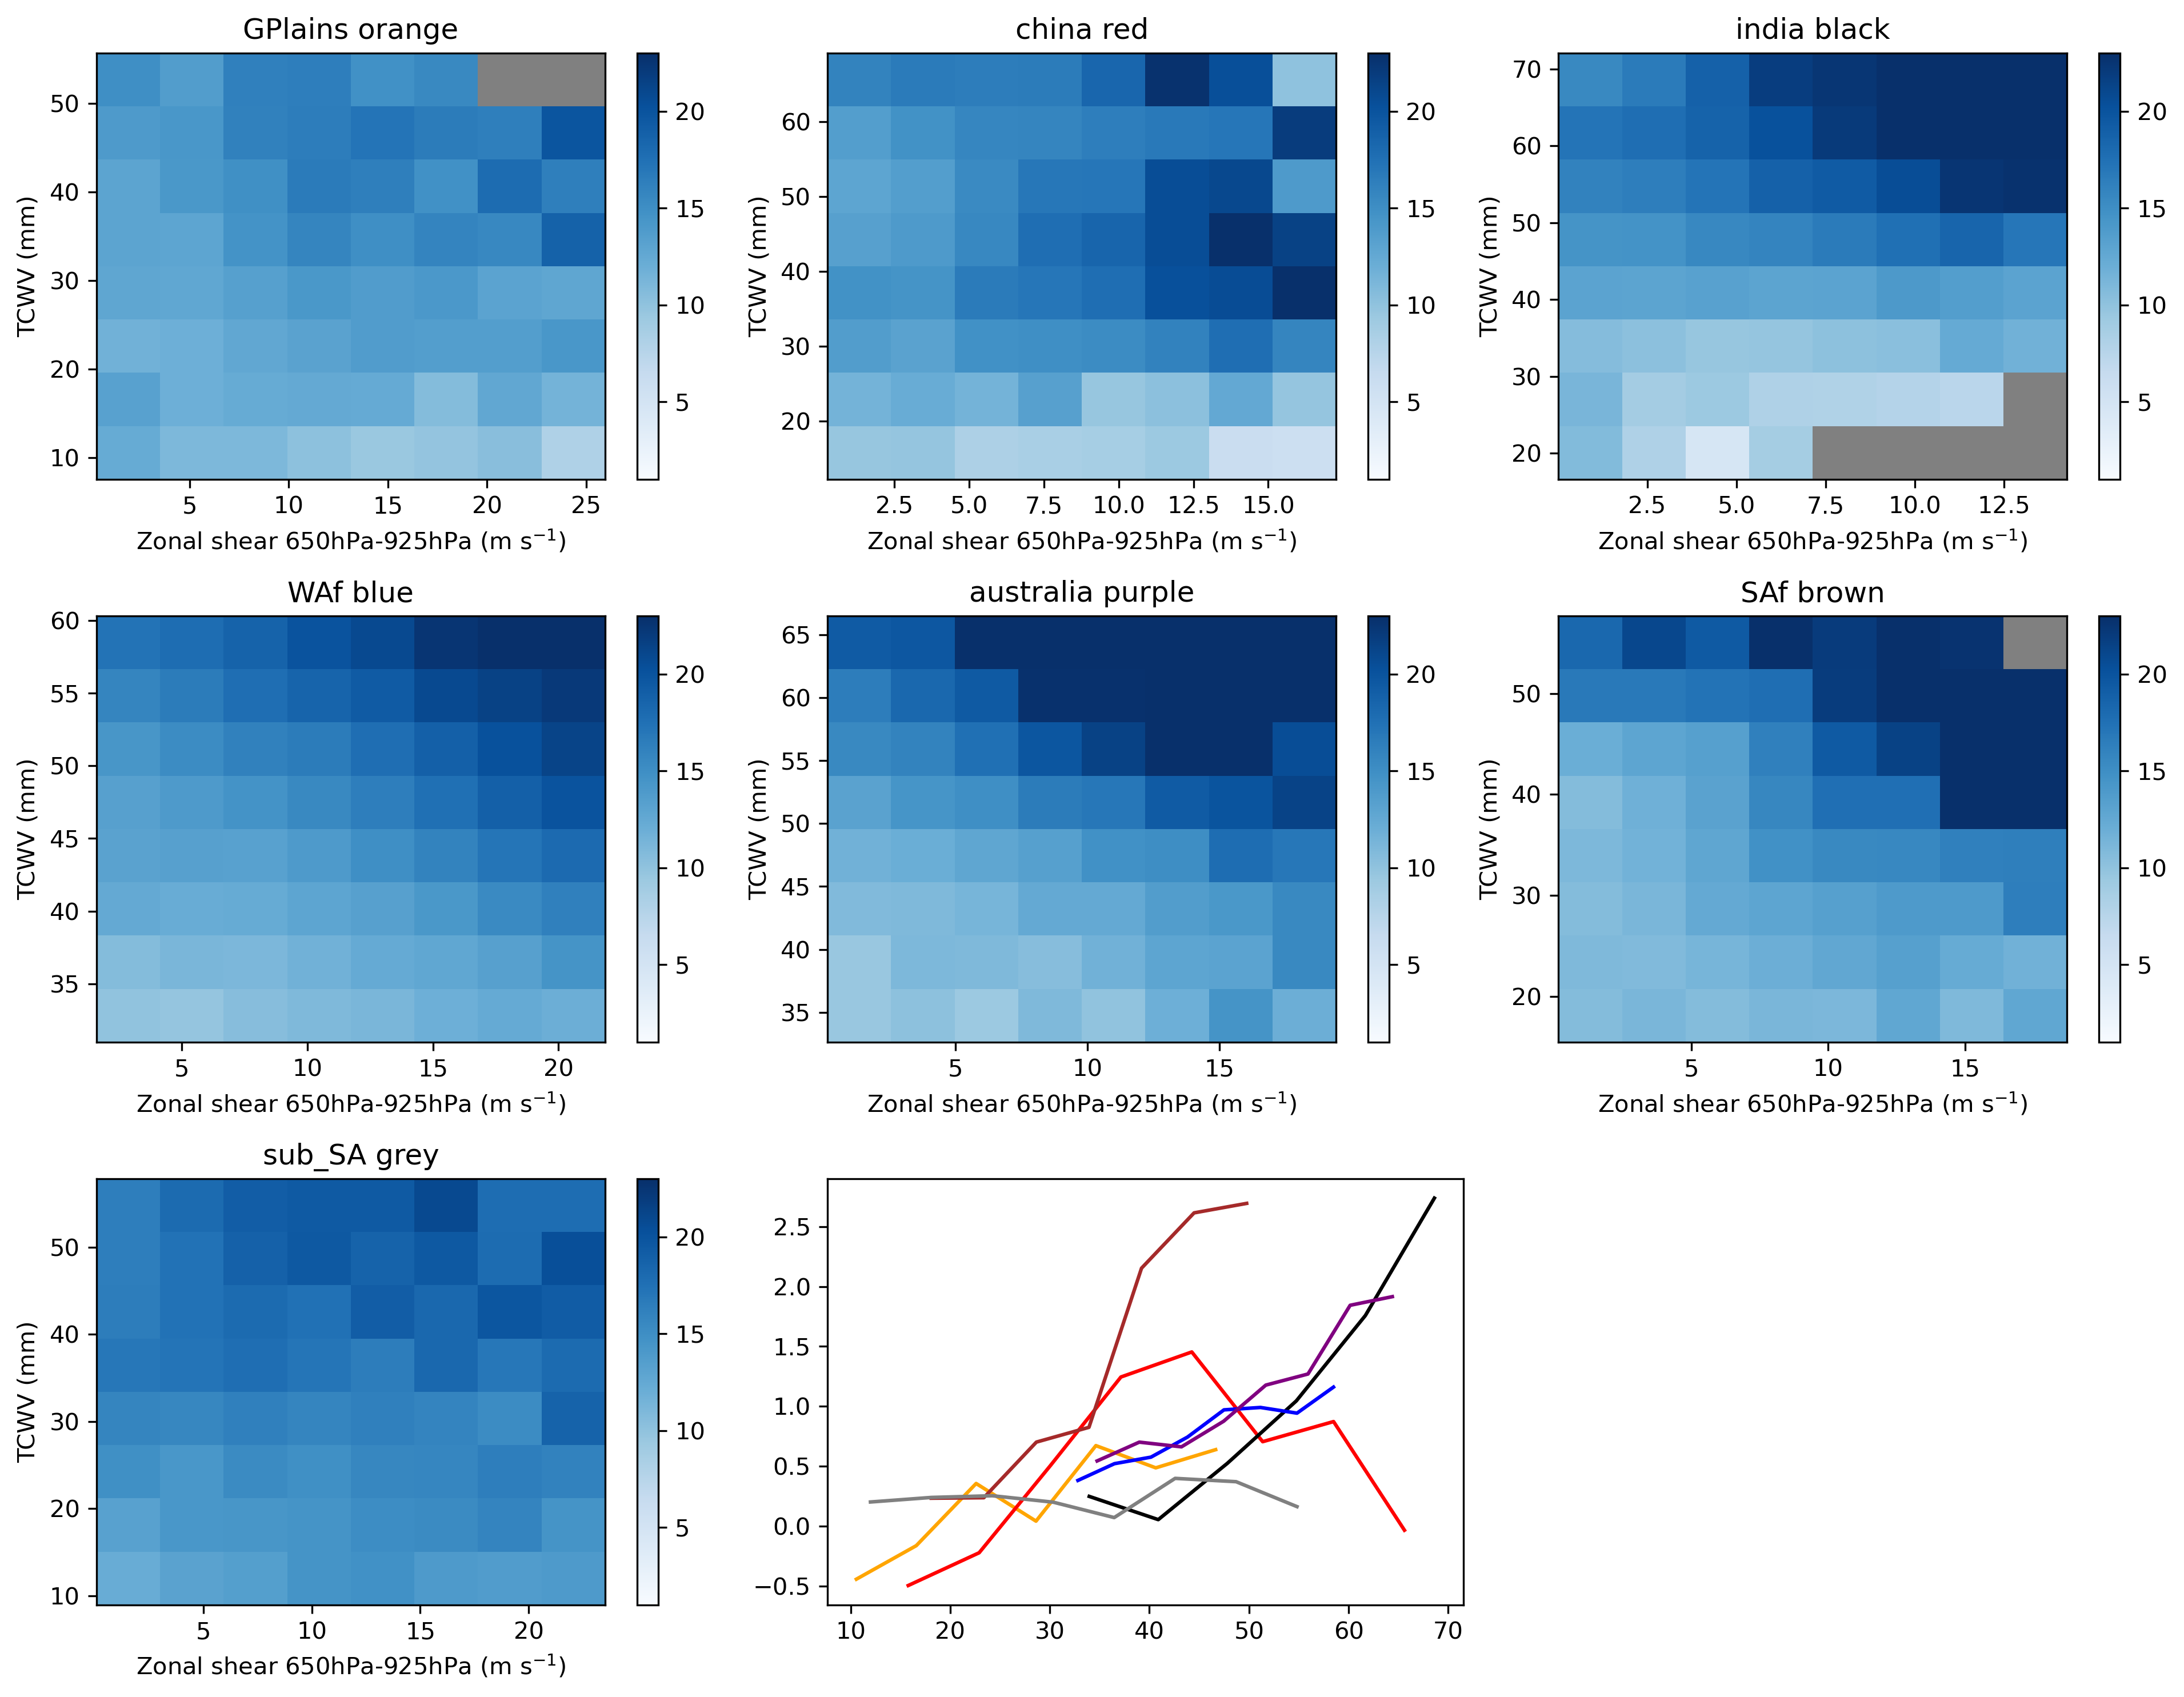

In [120]:
cs = ['orange', 'red', 'black', 'blue', 'purple', 'brown', 'grey', 'green', 'yellow']

prcp_vals = {'reg': [], 'slope' : [], 'pval' : []}

f= plt.figure(figsize=(13,10), dpi=300)
for ids, regs in enumerate(MREGIONS.keys()):
    ax = f.add_subplot(3,3,ids+1)
    
    pick = plot_regs[regs]

    shear = pick['shear'] * factor

    q = pick['tcwv']#(pick['q925'] + pick['q850'])/2

    sbin = np.linspace(np.nanpercentile(shear,1), np.nanpercentile(shear,99),9)
    tbin = np.linspace(np.nanpercentile(q,1), np.nanpercentile(q,99),9)
    testbins = [sbin,tbin]
    func1 = lambda y: np.mean(y) #np.percentile(y,95, interpolation='nearest') #np.percentile(y, 95)
    func2 = lambda y: np.sum(np.isfinite(y))
    func3 = lambda y: np.sum(y>1)

    xxu2 = shear.values.astype(np.float64)
    xxtc = q.values
    #xxtc = pick['q925'].values*1000
    xxch = pick['prcp'].values
    
   # ipdb.set_trace()
    
    ret = binned_statistic_2d(xxu2, xxtc, xxch, statistic=func1, bins=testbins)
    count = binned_statistic_2d(xxu2, xxtc, xxch, statistic=func2, bins=testbins)
    # thresh = binned_statistic_2d(xxu2, xxtc, xxch, statistic=func3, bins=testbins)

    dd=ret.statistic.T
    valid = count.statistic.T
    dd[valid<5] = np.nan

    mp = plt.pcolormesh(testbins[0], testbins[1], dd, cmap='Blues', vmin=1, vmax=23) #vmax=p2-1, vmin=0.5  ##p2-1
    plt.title(regs+' IQR ='+str(np.round(np.nanpercentile(xxch,75)-np.nanpercentile(xxch,25),2))+'K')
    plt.colorbar(mp)
    plt.title(regs+ ' ' + cs[ids])
    
    ax.set_ylabel('TCWV (mm)')
    ax.set_xlabel(r'Zonal shear 650hPa-925hPa (m s$^{-1}$)')
    
    ax.set_facecolor('grey')

    if ids == 0:
        ax1 = f.add_subplot(3,3,ids+8)

    x = np.arange(dd.shape[1])   # [0,1,2,3,4,5]

    slopes = np.full(dd.shape[0], np.nan)
    pvals  = np.full(dd.shape[0], np.nan)

    for j in range(dd.shape[0]):
        y = dd[j, :]
        res = linregress(x, y)
        slopes[j] = res.slope
        pvals[j] = res.pvalue

    prcp_vals = {'reg': MREGIONS.keys(), 'slope' : slopes, 'pval' : pvals}

    print("slopes:", slopes)
    print("pvals:", pvals)

    ax1.plot(testbins[1][0:-1]+(testbins[1][1::]-testbins[1][0:-1])/2, slopes, color=cs[ids])
plt.tight_layout()
#f.savefig(cnst.FIGS+'/LMCS/2dbins_pmax_TCWV_DYAMOND_100mshear.jpg')

slopes: [ 622.31792561  631.09890724 1891.82027187   10.20433862 2759.13743237
 1663.23749812 3160.8495747            nan]
pvals: [4.67540196e-01 2.34645143e-01 1.68435764e-02 9.91598481e-01
 4.07026758e-03 3.37770163e-01 3.54152104e-04            nan]
slopes: [-1286.54211752  1179.77854456   385.26248117  1065.91476632
   769.80684664   132.16230005   242.57206894 -1871.25037326]
pvals: [0.11879687 0.09173006 0.56548561 0.00870503 0.189618   0.8664157
 0.76576725 0.10928388]
slopes: [          nan           nan 1296.18545471 2098.05751504 1516.62720364
 2053.27000299 3551.1798979  6805.27500307]
pvals: [           nan            nan 8.85309789e-03 1.64242547e-05
 1.93086481e-03 7.54949468e-08 3.13120846e-05 2.65086992e-03]
slopes: [1534.25319899 2543.65658148 3132.47791084 3863.48401469 4020.59758816
 3788.15860835 2996.72934146 2736.73783529]
pvals: [5.08108487e-06 5.39046290e-06 1.50969986e-05 3.87116129e-07
 3.12319146e-06 1.68674556e-06 4.47969297e-07 3.01476923e-04]
slopes: [1685

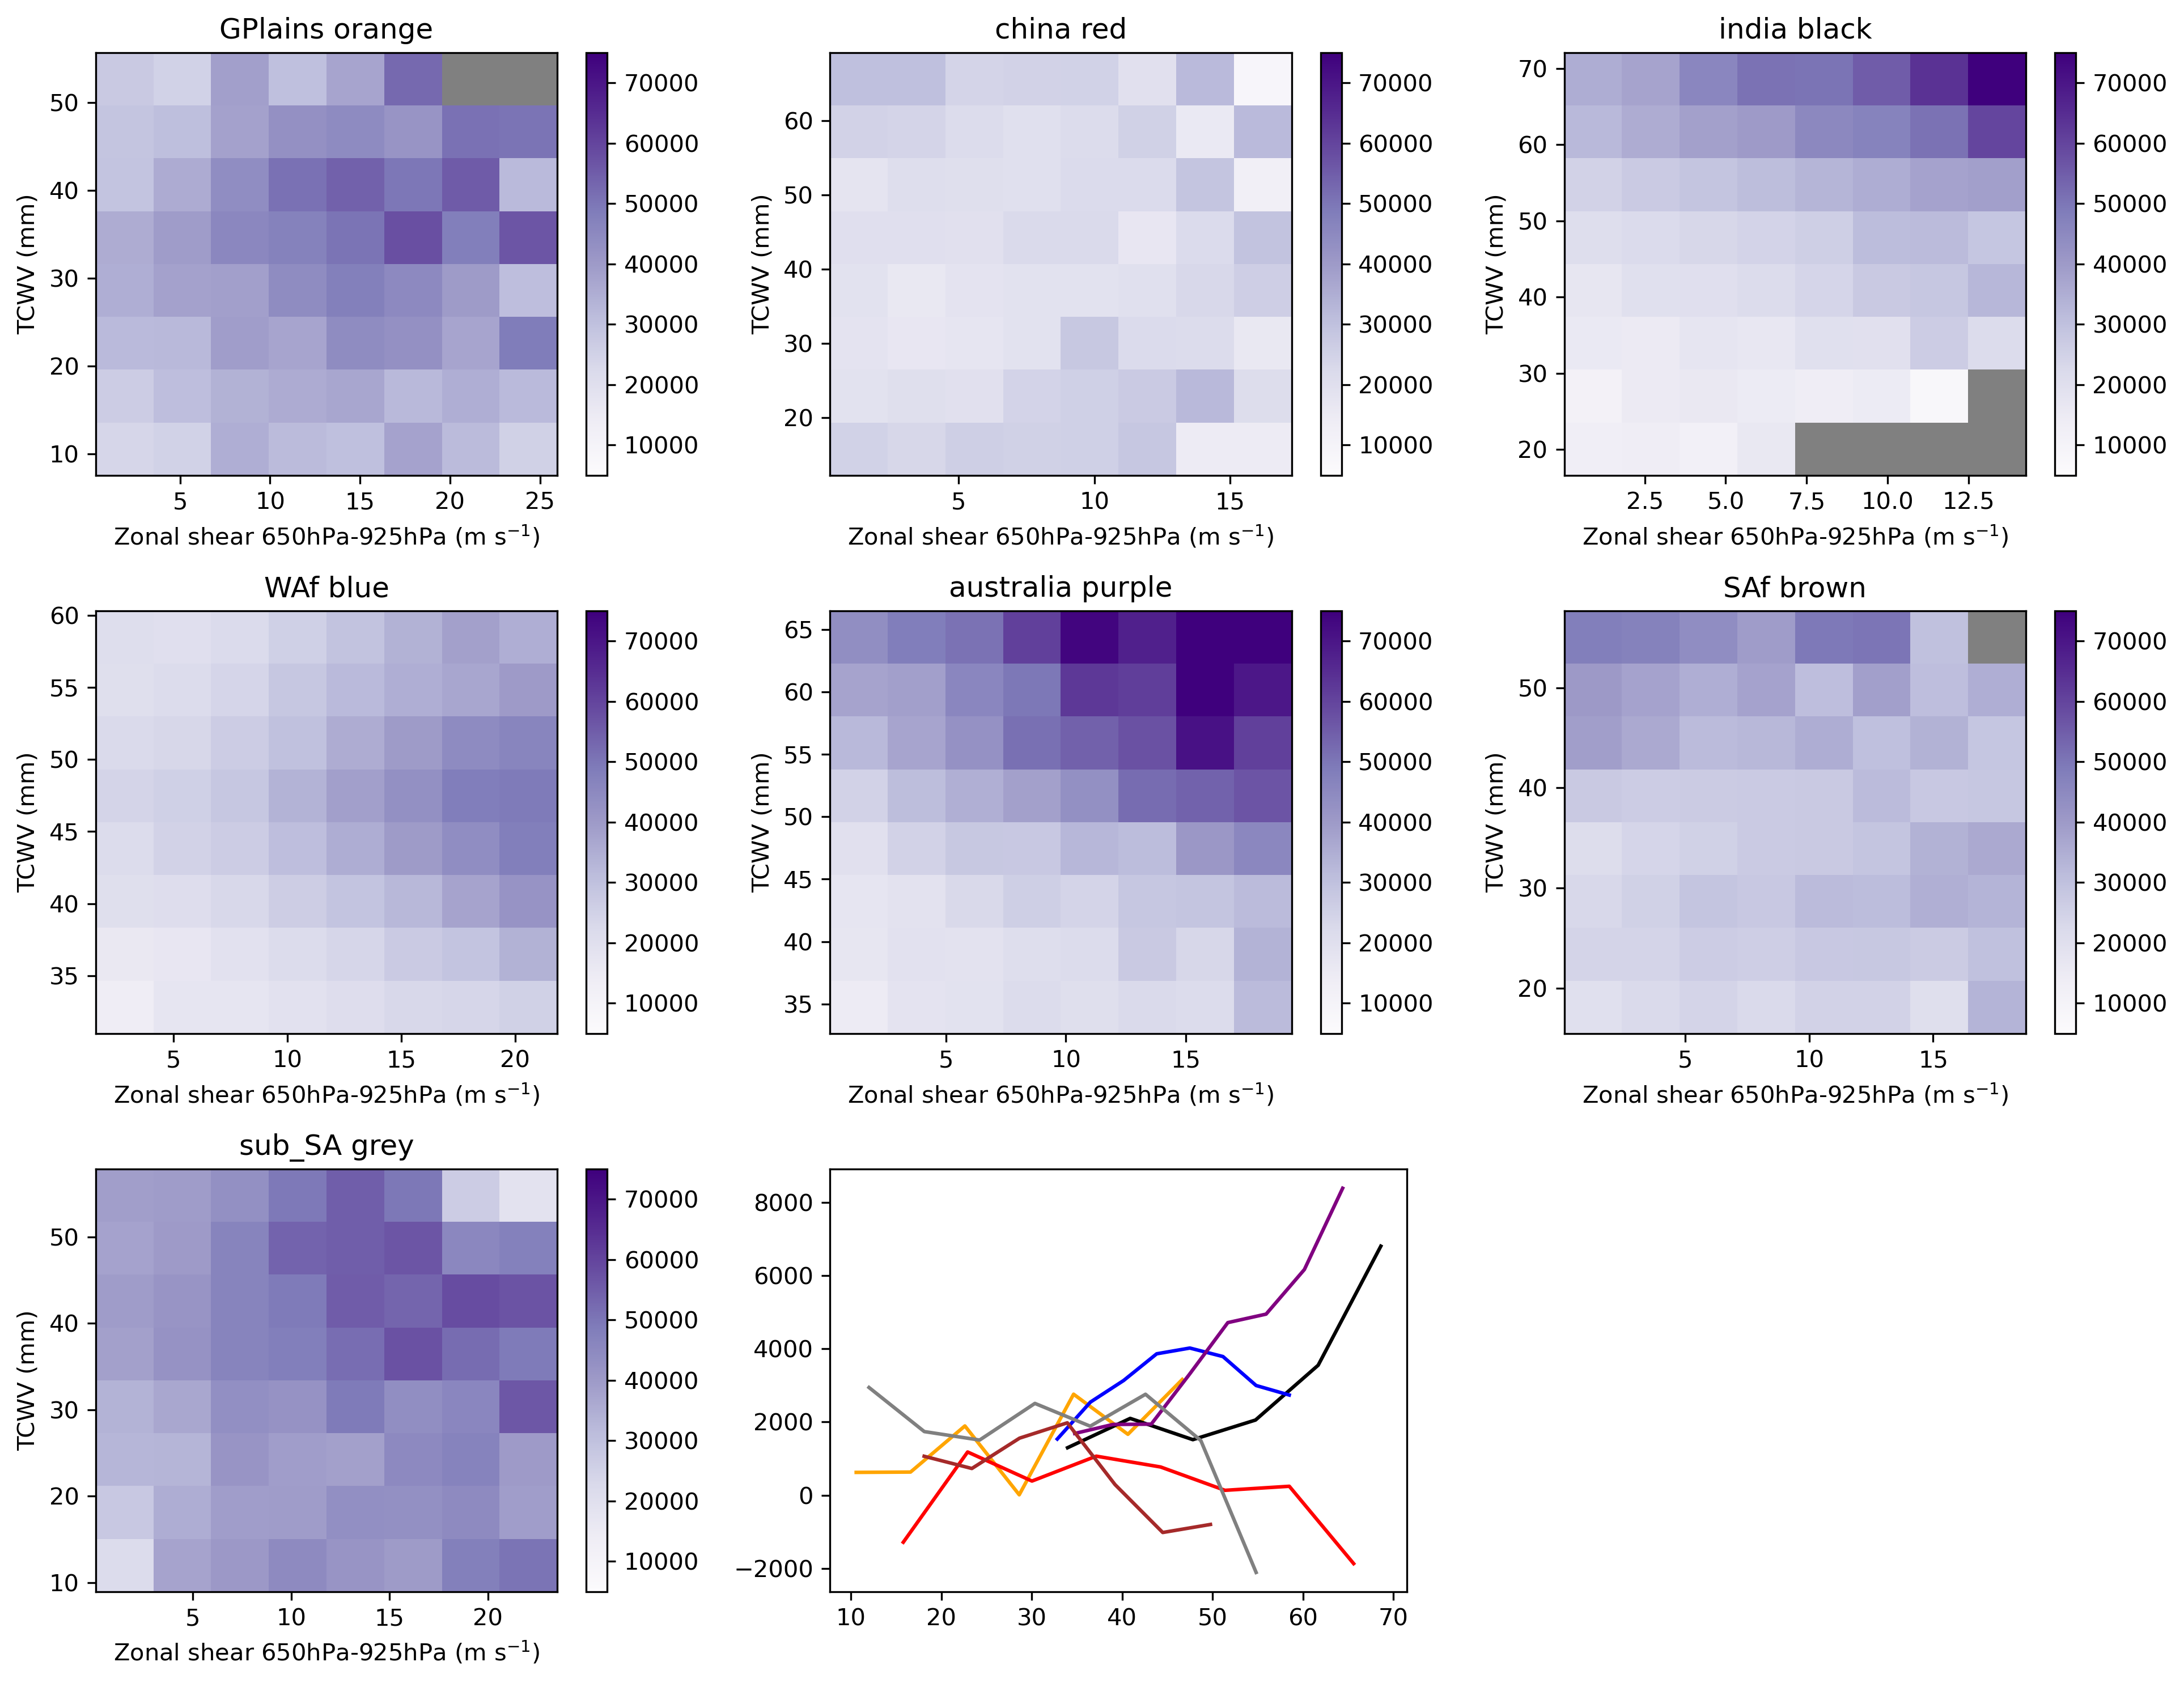

In [121]:
cs = ['orange', 'red', 'black', 'blue', 'purple', 'brown', 'grey', 'green', 'yellow']
area_vals = {'reg': [], 'slope' : [], 'pval' : []}
f= plt.figure(figsize=(13,10), dpi=300)
for ids, regs in enumerate(MREGIONS.keys()):
    ax = f.add_subplot(3,3,ids+1)
    
    pick = plot_regs[regs]
    
#     tbin = np.linspace(10,20,15)
#     #tbin = np.linspace(10,70,15)
#     sbin = np.linspace(-18,18,15)

    shear = pick['shear'] * factor

    sbin = np.linspace(np.nanpercentile(shear,1), np.nanpercentile(shear,99),9)
    tbin = np.linspace(np.nanpercentile(pick['tcwv'],1), np.nanpercentile(pick['tcwv'],99),9)
    testbins = [sbin,tbin]
    func1 = lambda y: np.mean(y) #np.percentile(y,95, interpolation='nearest') #np.percentile(y, 95)
    func2 = lambda y: np.sum(np.isfinite(y))
    func3 = lambda y: np.sum(y>1)

    xxu2 = shear.values.astype(np.float64) 
    xxtc = pick['tcwv'].values
    #xxtc = pick['q925'].values*1000
    xxch = pick['area'].values
    
   # ipdb.set_trace()
    
    ret = binned_statistic_2d(xxu2, xxtc, xxch, statistic=func1, bins=testbins)
    count = binned_statistic_2d(xxu2, xxtc, xxch, statistic=func2, bins=testbins)
    # thresh = binned_statistic_2d(xxu2, xxtc, xxch, statistic=func3, bins=testbins)

    dd=ret.statistic.T
    valid = count.statistic.T
    dd[valid<5] = np.nan

    mp = plt.pcolormesh(testbins[0], testbins[1], dd, cmap='Purples', vmin=5000, vmax=75000) #vmax=p2-1, vmin=0.5  ##p2-1
    plt.title(regs+' IQR ='+str(np.round(np.nanpercentile(xxch,75)-np.nanpercentile(xxch,25),2))+'K')
    plt.colorbar(mp)
    plt.title(regs+ ' ' + cs[ids])
    
    ax.set_ylabel('TCWV (mm)')
    ax.set_xlabel(r'Zonal shear 650hPa-925hPa (m s$^{-1}$)')
    
    ax.set_facecolor('grey')

    if ids == 0:
        ax1 = f.add_subplot(3,3,ids+8)

    x = np.arange(dd.shape[1])   # [0,1,2,3,4,5]

    slopes = np.full(dd.shape[0], np.nan)
    pvals  = np.full(dd.shape[0], np.nan)

    for j in range(dd.shape[0]):
        y = dd[j, :]
        res = linregress(x, y)
        slopes[j] = res.slope
        pvals[j] = res.pvalue

    print("slopes:", slopes)
    print("pvals:", pvals)

    area_vals = {'reg': MREGIONS.keys(), 'slope' : slopes, 'pval' : pvals}

    ax1.plot(testbins[1][0:-1]+(testbins[1][1::]-testbins[1][0:-1])/2, slopes, color=cs[ids])
plt.tight_layout()

In [ ]:
        for ax, response_col in zip(axes, [AREA_COL, PRECIP_COL]):
            sub = summary[summary['response'] == response_col]
    
            for region in region_list:
                rsub  = sub[sub['region'] == region].sort_values('bin_order')
                color = region_color[region]
                frac  = rsub['frac_slope'].values
                sig   = rsub['p_beta3'].iloc[0] < 0.05

                bin_x        = np.arange(len(frac))
    
                frac = rsub['frac_slope'].values
                frac_ci = rsub['frac_ci'].values
                
                ax.errorbar(bin_x, frac, yerr=frac_ci,
                            fmt='none', ecolor=color,
                            elinewidth=1.2, capsize=3, alpha=0.6, zorder=2)
                                
                ax.plot(bin_x, frac,
                        color=color, linewidth=1.8,
                        linestyle='-' if sig else '--',
                        alpha=0.85, zorder=2)
                
                ax.scatter(bin_x, frac,
                           color=color, s=70,
                           edgecolors='white', linewidths=0.6,
                           zorder=3)
    
                ax.annotate(region,
                            xy=(bin_x[-1], frac[-1]),
                            xytext=(6, 0),
                            textcoords='offset points',
                            fontsize=7.5, color=color, va='center')

                allfrac.append(frac[1])
    
            ax.axhline(1, color='#555555', linewidth=0.9, linestyle=':', zorder=1)
            ax.set_xticks(bin_x)
            ax.set_xticklabels([b[0] for b in TCW_BINS], fontsize=9)
            ax.set_ylabel('Shear slope relative to low-TCW bin', fontsize=10)
            ax.set_title(
                f'{response_col}  —  fractional shear amplification\n'
                f'(solid = p<0.05 interaction term)',
                fontsize=10, fontweight='bold')
            ax.spines[['top', 'right']].set_visible(False)
            ax.yaxis.grid(True, linestyle=':', alpha=0.45)
            ax.set_axisbelow(True)
            ax.set_xlim(-0.3, 2.9)

            
 
        handles = [plt.Line2D([0], [0], color=region_color[r],
                              linewidth=2, label=r) for r in region_list]
        axes[0].legend(handles=handles, title='Region',
                       fontsize=8, title_fontsize=9,
                       framealpha=0.9, edgecolor='#cccccc',
                       loc='upper left')
    
        fig.suptitle(
            f'Shear sensitivity increases with {TCW_COL}  —  within and across regions',
            fontsize=12, fontweight='bold', y=1.01)
    
        plt.tight_layout()

In [31]:
shear_scaling_plots.make_plots(plot_regs, outdir='/users/global/cornkle/pythonWorkspace/proj_CEH/COCOON/')

Saved -> /users/global/cornkle/pythonWorkspace/proj_CEH/COCOON//shear_scaling_area.png
Saved -> /users/global/cornkle/pythonWorkspace/proj_CEH/COCOON//shear_scaling_prcp.png


In [13]:
# for ids, regs in enumerate(MREGIONS.keys()):

#     plot_regs[regs].to_csv('/users/global/cornkle/pythonWorkspace/proj_CEH/COCOON/'+regs+'_plot_regs.csv')

In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import statsmodels.formula.api as smf
from scipy import stats

def plot_scaling_all(regions, shear='shear', tcw='tcwv', precip='prcp', area='area'):


    # ── CONFIG — only edit here ───────────────────────────────────────────────────
    SHEAR_COL  = shear
    TCW_COL    = tcw
    PRECIP_COL = precip
    AREA_COL   = area
    
    TCW_BINS = [
        ('Low\n(0–10th)',    0,  10),
        ('Mid\n(45–55th)',  45,  55),
        ('High\n(90–100th)',90, 100),

            # ('0–25th',   0,  25),
            # ('10–20th',  10, 20),
            # ('20–30th',  20, 30),
            # ('30–40th',  30, 40),
            # ('40–50th',  40, 50),
            # ('50–60th',  50, 60),
            # ('60–70th',  60, 70),
            # ('70–80th',  70, 80),
            # ('80–90th',  80, 90),
            # ('90–100th', 90, 100),

    ]
    
    TCW_CLIP_PERCENTILES = (1, 99)   # set to (0, 100) to disable clipping
    # ─────────────────────────────────────────────────────────────────────────────
    
    
    def clip_and_centre(df):
        """
        Shared preprocessing used by all steps:
          1. keep only the four analysis columns
          2. drop NaNs
          3. clip TCW to 1st-99th percentile to remove outliers
          4. centre TCW (after clipping) for the interaction model
        Returns a clean copy ready for analysis.
        """
        d = df[[TCW_COL, SHEAR_COL, AREA_COL, PRECIP_COL]].dropna().copy()
        lo = np.percentile(d[TCW_COL], TCW_CLIP_PERCENTILES[0])
        hi = np.percentile(d[TCW_COL], TCW_CLIP_PERCENTILES[1])
        d  = d[d[TCW_COL].between(lo, hi)].copy()
        if 'q' in TCW_COL:
            d[TCW_COL] = d[TCW_COL]*1000
        
        d['tcwv_c'] = d[TCW_COL]# - d[TCW_COL].mean()   # centre after clipping
        return d
    
    
        # ── STEP 1: direct OLS shear slope within each TCW bin ───────────────────────
    def bin_shear_slopes(d, response_col):
        bin_slopes = {}
        for label, lo, hi in TCW_BINS:
            lo_val = np.percentile(d[TCW_COL], lo)
            hi_val = np.percentile(d[TCW_COL], hi)
            mask   = d[TCW_COL].between(lo_val, hi_val)
            sub    = d[mask]
            slope, _, _, _, se = stats.linregress(sub[SHEAR_COL], sub[response_col])
            t_crit = stats.t.ppf(0.975, df=len(sub) - 2)
            bin_slopes[label] = {
                'slope':    slope,
                'ci':       t_crit * se,   # 95% CI half-width
                'mean_tcw': sub[TCW_COL].mean(),
                'n':        mask.sum(),
            }
        return bin_slopes
    
    
    # ── STEP 2: interaction model for p-value and beta3 ──────────────────────────
    def interaction_model(d, response_col):
        """
        Fit: response ~ tcwv_c * shear
        Uses centred tcwv so beta_shear is meaningful at mean tcwv.
        Returns (beta3, p_value_of_beta3).
        """
        m      = smf.ols(f'{response_col} ~ tcwv_c * {SHEAR_COL}', data=d).fit()
        beta3  = m.params[f'tcwv_c:{SHEAR_COL}']
        p_beta3 = m.pvalues[f'tcwv_c:{SHEAR_COL}']
        return beta3, p_beta3
    
    
    # ── STEP 3: fractional amplification ─────────────────────────────────────────
    def fractional_amplification(bin_slopes):
        """
        Express each bin's slope as a fraction of the low-TCW bin slope.
        Low bin = 1.0 by definition; values > 1 mean stronger shear sensitivity.
        """
        ref = bin_slopes[TCW_BINS[0][0]]['slope']
        return {
            label: vals['slope'] / ref if ref != 0 else np.nan
            for label, vals in bin_slopes.items()
        }
    
    
    # ── STEP 4: assemble summary table and plots ─────────────────────────────────
    def compute_all(regions):
        """
        Runs steps 1-3 for every region and response variable.
        Returns a long-form DataFrame with one row per (region, response, TCW bin).
        """
        records = []
    
        for region, df in regions.items():
            d = clip_and_centre(df)
    
            for response_col in [AREA_COL, PRECIP_COL]:
    
                # step 1: direct bin slopes
                bin_slopes = bin_shear_slopes(d, response_col)
                
                # step 2: interaction model
                beta3, p_beta3 = interaction_model(d, response_col)
                
                # step 3: fractional amplification — ref slope defined here
                ref_slope = bin_slopes[TCW_BINS[0][0]]['slope']
                
                for i, (label, lo, hi) in enumerate(TCW_BINS):
                    records.append({
                        'region':           region,
                        'response':         response_col,
                        'bin_label':        label,
                        'bin_order':        i,
                        'mean_tcw_bin':     bin_slopes[label]['mean_tcw'],
                        'n_bin':            bin_slopes[label]['n'],
                        'abs_slope':        bin_slopes[label]['slope'],
                        'ci':               bin_slopes[label]['ci'],
                        'frac_slope':       bin_slopes[label]['slope'] / ref_slope
                                            if ref_slope != 0 else np.nan,
                        'frac_ci':          bin_slopes[label]['ci'] / abs(ref_slope)
                                            if ref_slope != 0 else np.nan,
                        'beta3':            beta3,
                        'p_beta3':          p_beta3,
                        'mean_tcwv_region': d[TCW_COL].mean(),
                    })
    
        return pd.DataFrame(records)
    
    
    def plot_fractional(summary):
        """
        One panel per response variable.
        X axis: low / mid / high TCW bin.
        Y axis: shear slope as fraction of low-TCW bin slope (low = 1.0).
        Each region is a coloured line; solid = p<0.05, dashed = not significant.
        """
        region_list  = summary['region'].unique().tolist()
        palette      = cm.get_cmap('tab10', len(region_list))
        region_color = {r: palette(i) for i, r in enumerate(region_list)}
        
    
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        allfrac = []
        for ax, response_col in zip(axes, [AREA_COL, PRECIP_COL]):
            sub = summary[summary['response'] == response_col]
    
            for region in region_list:
                rsub  = sub[sub['region'] == region].sort_values('bin_order')
                color = region_color[region]
                frac  = rsub['frac_slope'].values
                sig   = rsub['p_beta3'].iloc[0] < 0.05

                bin_x        = np.arange(len(frac))
    
                frac = rsub['frac_slope'].values
                frac_ci = rsub['frac_ci'].values
                
                ax.errorbar(bin_x, frac, yerr=frac_ci,
                            fmt='none', ecolor=color,
                            elinewidth=1.2, capsize=3, alpha=0.6, zorder=2)
                                
                ax.plot(bin_x, frac,
                        color=color, linewidth=1.8,
                        linestyle='-' if sig else '--',
                        alpha=0.85, zorder=2)
                
                ax.scatter(bin_x, frac,
                           color=color, s=70,
                           edgecolors='white', linewidths=0.6,
                           zorder=3)
    
                ax.annotate(region,
                            xy=(bin_x[-1], frac[-1]),
                            xytext=(6, 0),
                            textcoords='offset points',
                            fontsize=7.5, color=color, va='center')

                allfrac.append(frac[1])
    
            ax.axhline(1, color='#555555', linewidth=0.9, linestyle=':', zorder=1)
            ax.set_xticks(bin_x)
            ax.set_xticklabels([b[0] for b in TCW_BINS], fontsize=9)
            ax.set_ylabel('Shear slope relative to low-TCW bin', fontsize=10)
            ax.set_title(
                f'{response_col}  —  fractional shear amplification\n'
                f'(solid = p<0.05 interaction term)',
                fontsize=10, fontweight='bold')
            ax.spines[['top', 'right']].set_visible(False)
            ax.yaxis.grid(True, linestyle=':', alpha=0.45)
            ax.set_axisbelow(True)
            ax.set_xlim(-0.3, 2.9)

            
 
        handles = [plt.Line2D([0], [0], color=region_color[r],
                              linewidth=2, label=r) for r in region_list]
        axes[0].legend(handles=handles, title='Region',
                       fontsize=8, title_fontsize=9,
                       framealpha=0.9, edgecolor='#cccccc',
                       loc='upper left')
    
        fig.suptitle(
            f'Shear sensitivity increases with {TCW_COL}  —  within and across regions',
            fontsize=12, fontweight='bold', y=1.01)
    
        plt.tight_layout()
        plt.savefig('fractional_shear_amplification.png', dpi=180, bbox_inches='tight')
        plt.show()
        print("Saved -> fractional_shear_amplification.png")
    
    
    def plot_beta3_scatter(summary):
        """
        Headline figure: mean regional TCWV vs beta3 interaction term.
        One point per region per response variable.
        Positive slope = moister regions have stronger shear-moisture coupling.
        """
        fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    
        for ax, response_col in zip(axes, [AREA_COL, PRECIP_COL]):
            # one row per region (beta3 is same across bins, take first)
            sub = (summary[summary['response'] == response_col]
                   .groupby('region')[['mean_tcwv_region', 'beta3', 'p_beta3']]
                   .first().reset_index())
    
            colors = ['#d6604d' if p < 0.05 else '#aaaaaa' for p in sub['p_beta3']]
            ax.scatter(sub['mean_tcwv_region'], sub['beta3'],
                       s=80, color=colors,
                       edgecolors='#333333', linewidths=0.6, zorder=3)
    
            for _, row in sub.iterrows():
                ax.annotate(row['region'],
                            (row['mean_tcwv_region'], row['beta3']),
                            fontsize=7.5,
                            textcoords='offset points', xytext=(4, 3))
    
            # regression line across regions
            if len(sub) > 2:
                m_reg = smf.ols('beta3 ~ mean_tcwv_region', data=sub).fit()
                x_range = np.linspace(sub['mean_tcwv_region'].min(),
                                      sub['mean_tcwv_region'].max(), 100)
                ax.plot(x_range,
                        m_reg.predict(pd.DataFrame({'mean_tcwv_region': x_range})),
                        color='#d6604d', linewidth=1.5, linestyle='--', alpha=0.8)
                ax.text(0.05, 0.92, f'R²={m_reg.rsquared:.2f}',
                        transform=ax.transAxes, fontsize=9, color='#d6604d')
    
            ax.axhline(0, color='#555555', linewidth=0.8, linestyle='--')
            ax.set_xlabel(f'Mean regional {TCW_COL} (kg/m²)', fontsize=9)
            ax.set_ylabel('β₃ interaction term (shear × TCWV)', fontsize=9)
            ax.set_title(f'Interaction strength vs mean regional moisture\n({response_col})',
                         fontsize=10, fontweight='bold')
            ax.spines[['top', 'right']].set_visible(False)
            ax.grid(True, linestyle=':', alpha=0.4)

            # ax.set_xticks(sub['mean_tcwv_region'].round(0).values)
            # ax.set_xticklabels([f'{v:.0f}' for v in sub['mean_tcwv_region'].values],
            #        fontsize=8, rotation=45)
    
        plt.tight_layout()
        plt.savefig('beta3_scatter.png', dpi=180, bbox_inches='tight')
        plt.show()
        print("Saved -> beta3_scatter.png")
    
    
    # ── RUN ───────────────────────────────────────────────────────────────────────
    summary = compute_all(regions)
    
    # print summary table
    pivot = summary.pivot_table(
        index=['region', 'response'],
        columns='bin_label',
        values='frac_slope'
    ).round(2)
    print(pivot.to_string())
    
    plot_fractional(summary)
    plot_beta3_scatter(summary)

bin_label           High\n(90–100th)  Low\n(0–10th)  Mid\n(45–55th)
region    response                                                 
GPlains   area                  2.77            1.0            2.89
          prcp                  0.90            1.0            1.52
SAf       area                  1.61            1.0            2.66
          prcp                  1.71            1.0            2.24
WAf       area                  3.26            1.0            2.68
          prcp                  3.08            1.0            2.24
australia area                  3.15            1.0            1.91
          prcp                  3.00            1.0            1.11
china     area                  3.78            1.0            1.70
          prcp                  6.44            1.0            5.72
india     area                  4.98            1.0            1.36
          prcp                  4.42            1.0            2.04
sub_SA    area                  2.71            

/tmp/ipykernel_1183771/2447640383.py:156: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette      = cm.get_cmap('tab10', len(region_list))


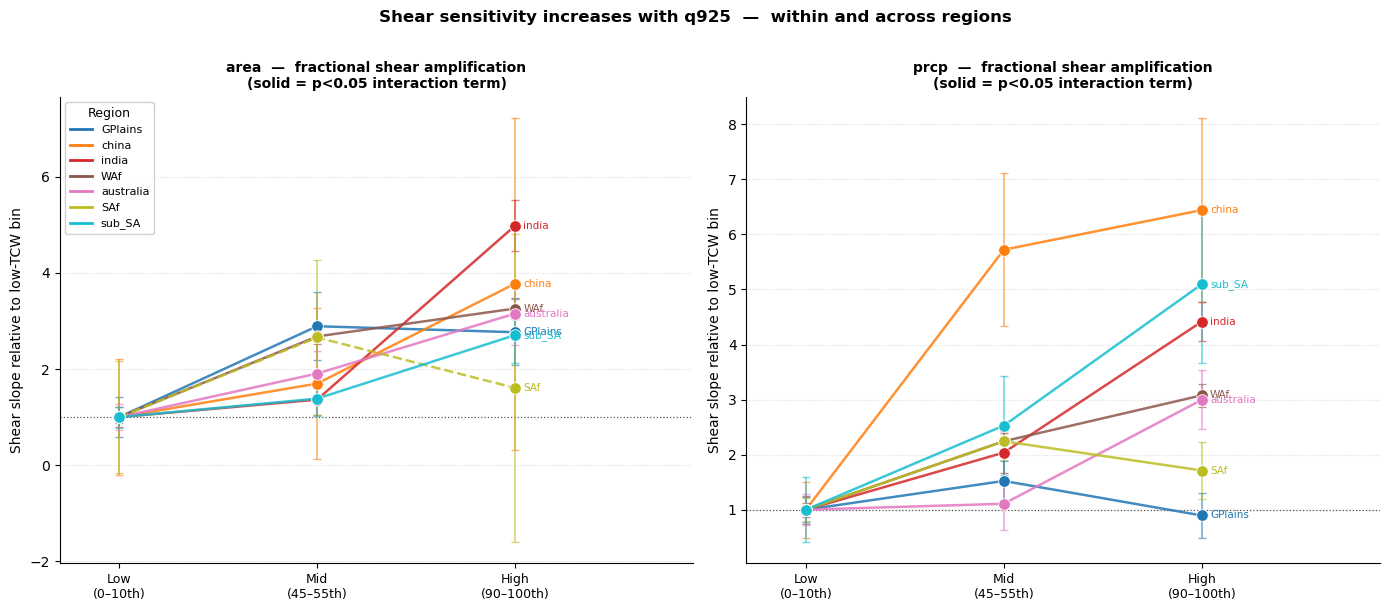

Saved -> fractional_shear_amplification.png


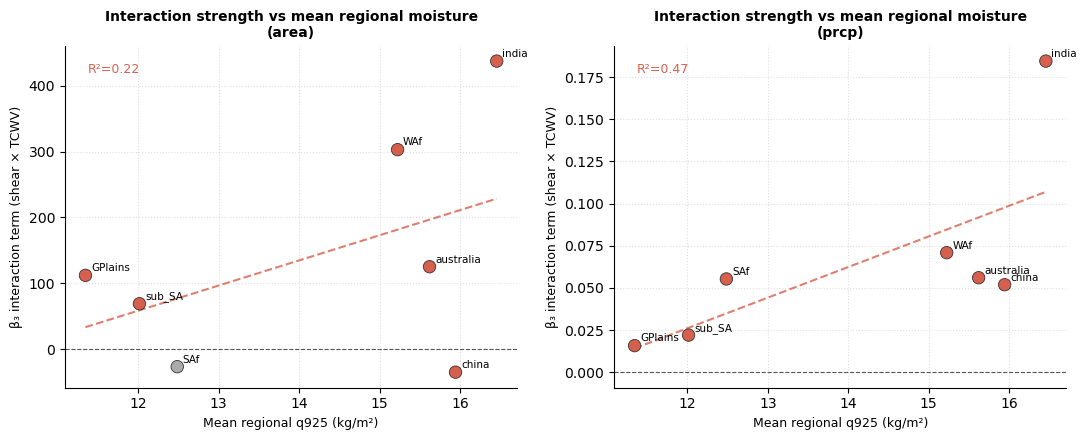

Saved -> beta3_scatter.png


In [92]:
plot_scaling_all(plot_regs, shear = 'shear', tcw='q925', precip='prcp', area='area')

In [108]:
from COCOON import shear_scaling_plots_lines_v2 as pline #plot_absolute, plot_fractional_lines, plot_allregion
from COCOON import shear_scaling_plots_bars_v2  as pbars

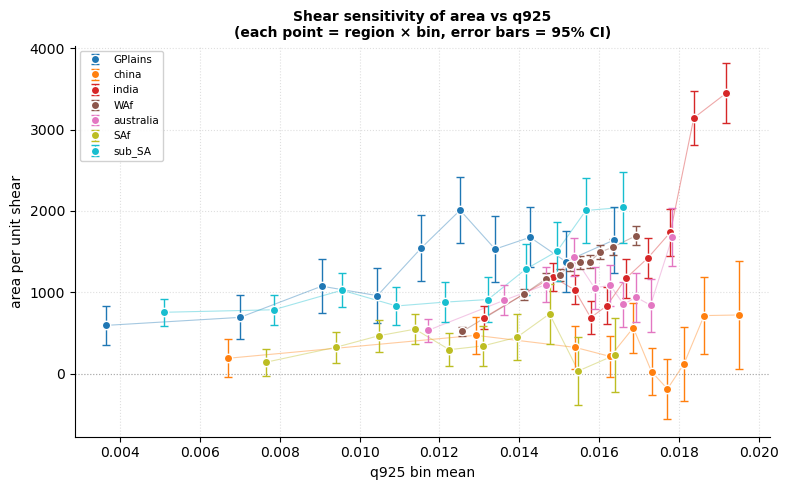

Saved -> absolute_q925_area.png


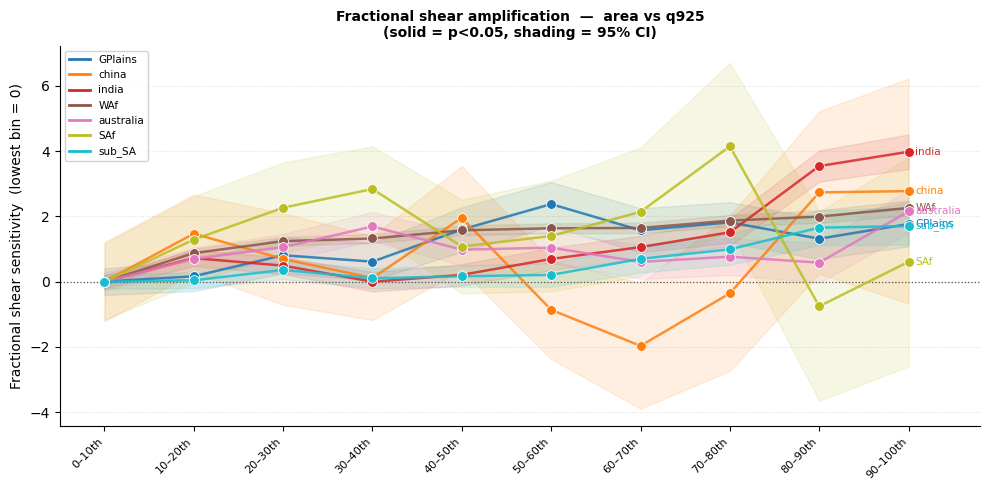

Saved -> fractional_lines_q925_area.png


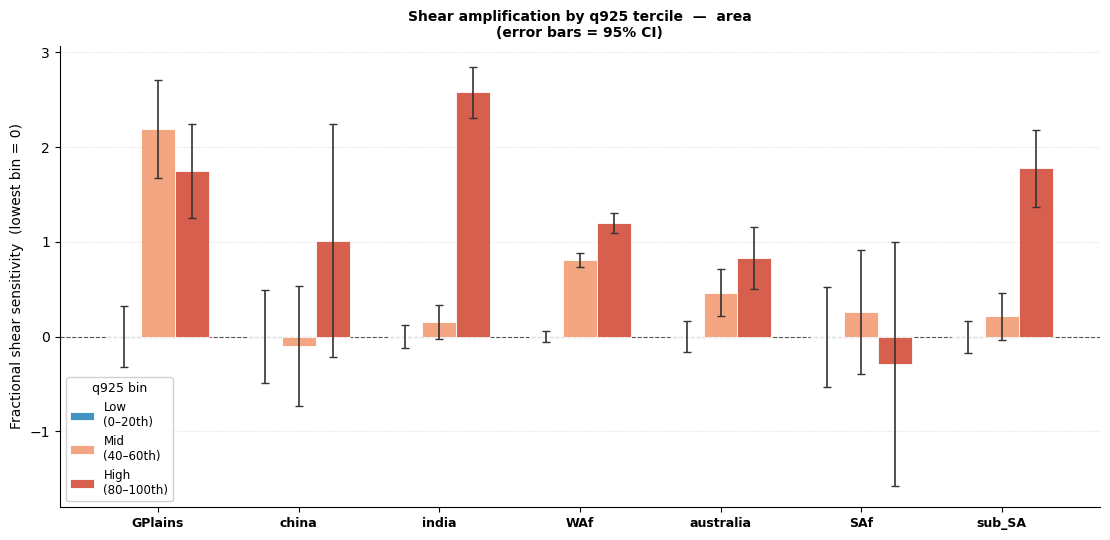

Saved -> fractional_bars_q925_area.png


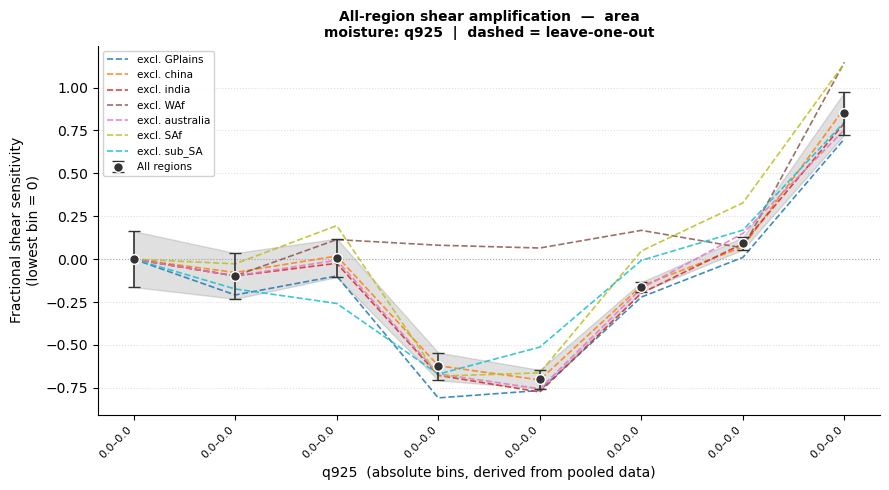

Saved -> allregion_q925_area.png


In [111]:
var1 = 'shear'
var2 = 'q925'
target_var='area'

pline.plot_absolute(plot_regs, var1=var1, var2=var2, target_var=target_var)
pline.plot_fractional_lines(plot_regs, var1=var1, var2=var2, target_var=target_var)
pbars.plot_fractional_bars(plot_regs, var1=var1, var2=var2, target_var=target_var)
pline.plot_allregion(plot_regs, var1=var1, var2=var2, target_var=target_var)